# Stage 1: Ingestion

| Version | Date | Author | Description |
| --- | --- | --- | --- |
| 1.0.0 | 2026-01-25 | That Le | Stage 1 exploration notebook |

## Overview

Stage 1 transforms diverse input formats into normalized images:

- **Input**: PDF, DOCX, PNG, JPG
- **Output**: List of clean, normalized images
- **Key Libraries**: PyMuPDF (fitz), Pillow, OpenCV

## 1. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# PDF library
import fitz  # PyMuPDF

print(f"Project root: {PROJECT_ROOT}")
print(f"PyMuPDF version: {fitz.version}")

Project root: d:\elix\chart_analysis_ai_v3
PyMuPDF version: ('1.26.7', '1.26.12', None)


## 2. PDF to Images Conversion

In [2]:
def pdf_to_images(pdf_path: Path, dpi: int = 150) -> list:
    """
    Convert PDF pages to images.
    
    Args:
        pdf_path: Path to PDF file
        dpi: Resolution for rendering (default 150)
        
    Returns:
        List of numpy arrays (images)
    """
    doc = fitz.open(pdf_path)
    images = []
    
    for page_num, page in enumerate(doc):
        # Create transformation matrix for DPI
        mat = fitz.Matrix(dpi / 72, dpi / 72)
        
        # Render page to pixmap
        pix = page.get_pixmap(matrix=mat)
        
        # Convert to numpy array
        img = np.frombuffer(pix.samples, dtype=np.uint8)
        img = img.reshape(pix.height, pix.width, pix.n)
        
        # Convert RGBA to RGB if needed
        if pix.n == 4:
            img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
        
        images.append(img)
        print(f"Page {page_num + 1}: {pix.width}x{pix.height}")
    
    doc.close()
    return images

print("Function defined: pdf_to_images()")

Function defined: pdf_to_images()


In [3]:
# Find PDF files
pdf_dirs = [
    PROJECT_ROOT / "data" / "raw_pdfs",
    PROJECT_ROOT / "data" / "raw",
]

pdf_files = []
for pdf_dir in pdf_dirs:
    if pdf_dir.exists():
        pdf_files.extend(list(pdf_dir.glob("*.pdf")))

print(f"Found {len(pdf_files)} PDF files")

if pdf_files:
    for pdf in pdf_files[:5]:
        print(f"  - {pdf.name}")

Found 889 PDF files
  - arxiv_1301_3342v2.pdf
  - arxiv_1512_03385v1.pdf
  - arxiv_1704_06687v1.pdf
  - arxiv_1706_03762v7.pdf
  - arxiv_1710_07300v2.pdf


Converting: arxiv_1301_3342v2.pdf
Page 1: 1275x1650
Page 2: 1275x1650
Page 3: 1275x1650
Page 4: 1275x1650
Page 5: 1275x1650
Page 6: 1275x1650
Page 7: 1275x1650
Page 8: 1275x1650
Page 9: 1275x1650
Page 10: 1275x1650
Page 11: 1275x1650


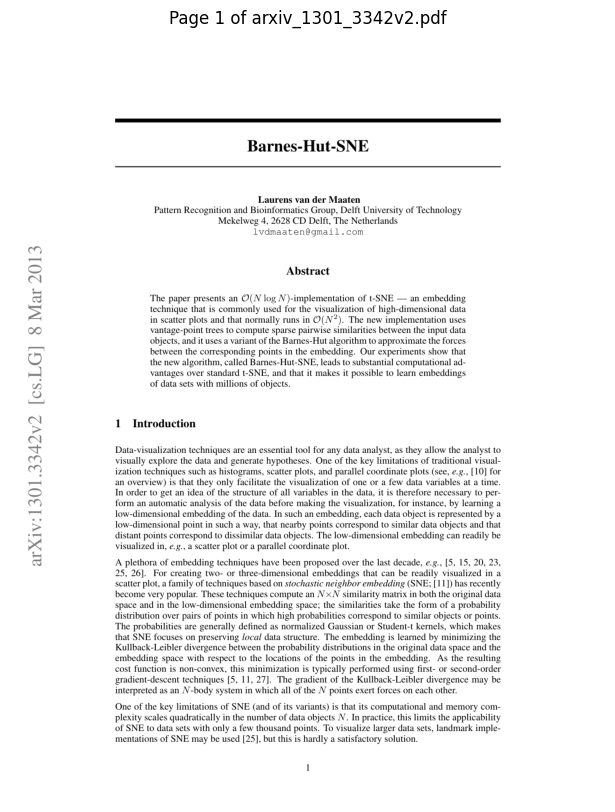

In [4]:
# Convert first PDF (if any)
if pdf_files:
    pdf_path = pdf_files[0]
    print(f"Converting: {pdf_path.name}")
    
    images = pdf_to_images(pdf_path, dpi=150)
    
    # Display first page
    if images:
        plt.figure(figsize=(12, 10))
        plt.imshow(images[0])
        plt.title(f"Page 1 of {pdf_path.name}")
        plt.axis('off')
        plt.show()
else:
    print("No PDF files found. Add PDFs to data/raw_pdfs/")

## 3. Image Quality Validation

In [2]:
def check_image_quality(image: np.ndarray) -> dict:
    """
    Check image quality metrics.
    
    Returns:
        Dict with quality metrics
    """
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image
    
    # 1. Blur detection (Laplacian variance)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    blur_score = laplacian.var()
    
    # 2. Contrast (standard deviation)
    contrast = gray.std()
    
    # 3. Brightness (mean)
    brightness = gray.mean()
    
    # 4. Resolution check
    height, width = gray.shape
    resolution_ok = min(width, height) >= 300
    
    return {
        'width': width,
        'height': height,
        'blur_score': blur_score,
        'is_blurry': blur_score < 100,
        'contrast': contrast,
        'brightness': brightness,
        'resolution_ok': resolution_ok,
    }

print("Function defined: check_image_quality()")

Function defined: check_image_quality()


In [3]:
# Test on sample images
sample_dir = PROJECT_ROOT / "data" / "academic_dataset" / "images"
sample_images = list(sample_dir.glob("*.png"))[:5] if sample_dir.exists() else []

if sample_images:
    print("Quality Analysis Results")
    print("=" * 60)
    
    for img_path in sample_images:
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        quality = check_image_quality(img)
        
        status = "OK" if not quality['is_blurry'] and quality['resolution_ok'] else "WARN"
        print(f"[{status}] {img_path.name}")
        print(f"     Size: {quality['width']}x{quality['height']}")
        print(f"     Blur: {quality['blur_score']:.1f}, Contrast: {quality['contrast']:.1f}")
        print()
else:
    print("No sample images found")

Quality Analysis Results
[OK] arxiv_1301_3342v2_p05_img01.png
     Size: 1476x1143
     Blur: 964.8, Contrast: 33.1

[OK] arxiv_1301_3342v2_p05_img02.png
     Size: 1464x1143
     Blur: 1191.5, Contrast: 35.5

[OK] arxiv_1301_3342v2_p06_img01.png
     Size: 1476x1143
     Blur: 1470.6, Contrast: 42.0

[OK] arxiv_1301_3342v2_p06_img02.png
     Size: 1464x1143
     Blur: 1735.4, Contrast: 42.4

[OK] arxiv_1301_3342v2_p11_img01.png
     Size: 1476x1143
     Blur: 971.0, Contrast: 32.6



## 4. Image Normalization

In [4]:
def normalize_image(image: np.ndarray, max_size: int = 2048) -> np.ndarray:
    """
    Normalize image for pipeline processing.
    
    Steps:
    1. Resize if too large
    2. Enhance contrast (CLAHE)
    """
    h, w = image.shape[:2]
    
    # 1. Resize if needed
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        new_w = int(w * scale)
        new_h = int(h * scale)
        image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
        print(f"Resized: {w}x{h} -> {new_w}x{new_h}")
    
    # 2. CLAHE contrast enhancement
    if len(image.shape) == 3:
        # Convert to LAB
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        
        # Apply CLAHE to L channel
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l = clahe.apply(l)
        
        # Merge and convert back
        lab = cv2.merge([l, a, b])
        image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    else:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        image = clahe.apply(image)
    
    return image

print("Function defined: normalize_image()")

Function defined: normalize_image()


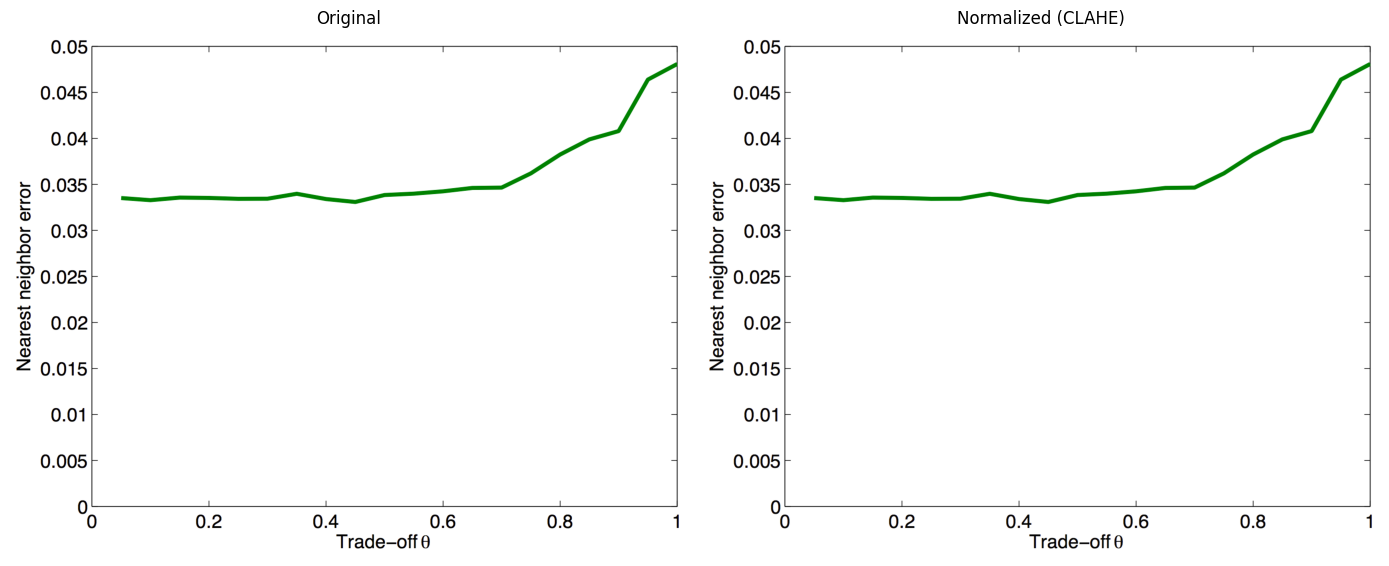

In [5]:
# Demo normalization
if sample_images:
    img_path = sample_images[0]
    original = cv2.imread(str(img_path))
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    
    normalized = normalize_image(original.copy())
    
    # Compare
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    axes[1].imshow(normalized)
    axes[1].set_title("Normalized (CLAHE)")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

## Summary

Stage 1 provides:

1. **PDF Conversion**: `pdf_to_images()` - PyMuPDF for high-quality rendering
2. **Quality Check**: `check_image_quality()` - Blur, contrast, resolution validation
3. **Normalization**: `normalize_image()` - CLAHE enhancement for better OCR

**Next**: Stage 2 - YOLO Detection (`02_stage2_detection.ipynb`)

# Stage 1: Ingestion - PDF/Image Loading

| Version | Date | Author | Description |
| --- | --- | --- | --- |
| 1.0.0 | 2026-01-25 | That Le | Stage 1 exploration notebook |

## Overview

Stage 1 handles input file processing:

| Input | Process | Output |
| --- | --- | --- |
| PDF | Convert pages to images | List of CleanImage |
| DOCX | Extract embedded images | List of CleanImage |
| PNG/JPG | Load and normalize | CleanImage |

### Key Operations:
1. **File Type Detection** - Identify input format
2. **Page Conversion** - PDF pages to images (PyMuPDF)
3. **Quality Validation** - Resolution, blur detection
4. **Normalization** - Resize, enhance contrast

## 1. Setup

In [6]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# PyMuPDF for PDF processing
try:
    import fitz  # PyMuPDF
    HAS_PYMUPDF = True
except ImportError:
    HAS_PYMUPDF = False
    print("PyMuPDF not installed. Install with: pip install pymupdf")

print(f"Project root: {PROJECT_ROOT}")
print(f"PyMuPDF available: {HAS_PYMUPDF}")

Project root: d:\elix\chart_analysis_ai_v3
PyMuPDF available: True


## 2. PDF to Images Conversion

In [7]:
def pdf_to_images(pdf_path: Path, dpi: int = 150) -> list:
    """
    Convert PDF pages to images using PyMuPDF.
    
    Args:
        pdf_path: Path to PDF file
        dpi: Resolution for rendering (default 150)
        
    Returns:
        List of numpy arrays (images)
    """
    if not HAS_PYMUPDF:
        raise ImportError("PyMuPDF required")
    
    doc = fitz.open(pdf_path)
    images = []
    
    for page_num, page in enumerate(doc):
        # Calculate zoom factor from DPI
        zoom = dpi / 72  # PDF default is 72 DPI
        mat = fitz.Matrix(zoom, zoom)
        
        # Render page to pixmap
        pix = page.get_pixmap(matrix=mat)
        
        # Convert to numpy array
        img = np.frombuffer(pix.samples, dtype=np.uint8)
        img = img.reshape(pix.height, pix.width, pix.n)
        
        # Convert RGBA to RGB if needed
        if pix.n == 4:
            img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
        
        images.append({
            'page': page_num + 1,
            'image': img,
            'width': pix.width,
            'height': pix.height
        })
        
    doc.close()
    return images

print("PDF conversion function defined")

PDF conversion function defined


Found 889 PDF files

Processing: arxiv_1301_3342v2.pdf
Converted 11 pages


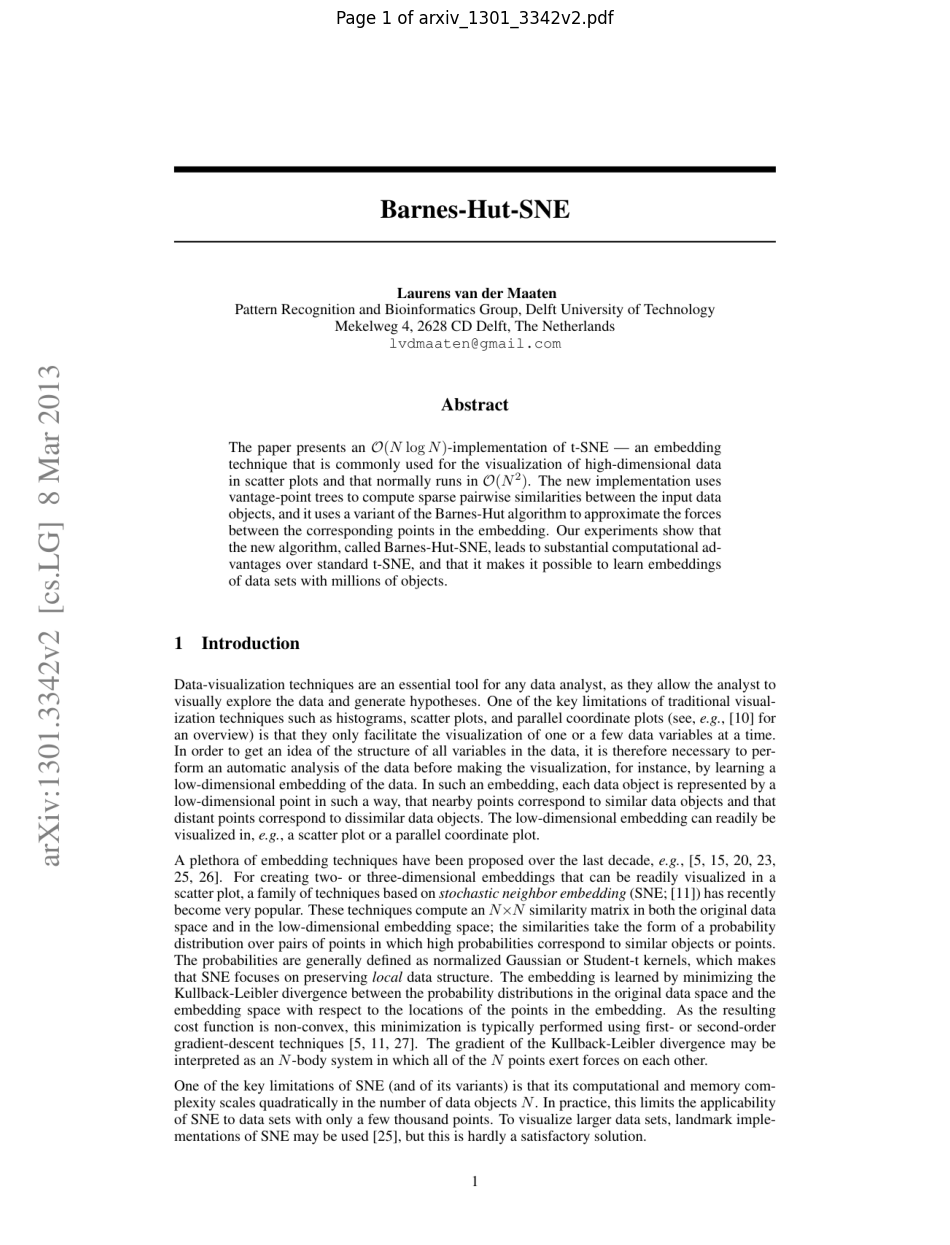

In [8]:
# Find sample PDF
pdf_dirs = [
    PROJECT_ROOT / "data" / "raw_pdfs",
    PROJECT_ROOT / "data" / "raw",
]

sample_pdfs = []
for pdf_dir in pdf_dirs:
    if pdf_dir.exists():
        sample_pdfs.extend(list(pdf_dir.glob("*.pdf")))

print(f"Found {len(sample_pdfs)} PDF files")

if sample_pdfs and HAS_PYMUPDF:
    pdf_path = sample_pdfs[0]
    print(f"\nProcessing: {pdf_path.name}")
    
    pages = pdf_to_images(pdf_path, dpi=150)
    print(f"Converted {len(pages)} pages")
    
    # Show first page
    if pages:
        plt.figure(figsize=(12, 16))
        plt.imshow(pages[0]['image'])
        plt.title(f"Page 1 of {pdf_path.name}")
        plt.axis('off')
        plt.show()
else:
    print("No PDFs found or PyMuPDF not available")

## 3. Image Quality Validation

In [9]:
def check_image_quality(image: np.ndarray) -> dict:
    """
    Check image quality metrics.
    
    Returns:
        Dict with quality metrics
    """
    h, w = image.shape[:2]
    
    # Convert to grayscale for analysis
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image
    
    # Blur detection using Laplacian variance
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    is_blurry = laplacian_var < 100  # Threshold for blur
    
    # Resolution check
    min_dimension = min(w, h)
    is_low_res = min_dimension < 200
    
    # Contrast check
    contrast = gray.std()
    is_low_contrast = contrast < 30
    
    return {
        'width': w,
        'height': h,
        'blur_score': laplacian_var,
        'is_blurry': is_blurry,
        'contrast': contrast,
        'is_low_contrast': is_low_contrast,
        'is_low_res': is_low_res,
        'passed': not (is_blurry or is_low_res or is_low_contrast)
    }

print("Quality check function defined")

Quality check function defined


In [10]:
# Test quality check on sample images
sample_dirs = [
    PROJECT_ROOT / "data" / "academic_dataset" / "images",
    PROJECT_ROOT / "data" / "samples",
]

sample_images = []
for sample_dir in sample_dirs:
    if sample_dir.exists():
        sample_images.extend(list(sample_dir.glob("*.png"))[:5])

print(f"Checking quality of {len(sample_images)} images:\n")

for img_path in sample_images:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    quality = check_image_quality(img)
    
    status = "[PASS]" if quality['passed'] else "[FAIL]"
    print(f"{status} {img_path.name}")
    print(f"       Size: {quality['width']}x{quality['height']}")
    print(f"       Blur score: {quality['blur_score']:.1f}")
    print(f"       Contrast: {quality['contrast']:.1f}")
    print()

Checking quality of 5 images:

[PASS] arxiv_1301_3342v2_p05_img01.png
       Size: 1476x1143
       Blur score: 964.8
       Contrast: 33.1

[PASS] arxiv_1301_3342v2_p05_img02.png
       Size: 1464x1143
       Blur score: 1191.5
       Contrast: 35.5

[PASS] arxiv_1301_3342v2_p06_img01.png
       Size: 1476x1143
       Blur score: 1470.6
       Contrast: 42.0

[PASS] arxiv_1301_3342v2_p06_img02.png
       Size: 1464x1143
       Blur score: 1735.4
       Contrast: 42.4

[PASS] arxiv_1301_3342v2_p11_img01.png
       Size: 1476x1143
       Blur score: 971.0
       Contrast: 32.6



## 4. Image Normalization

In [11]:
def normalize_image(
    image: np.ndarray,
    max_size: int = 2048,
    enhance_contrast: bool = True
) -> np.ndarray:
    """
    Normalize image for pipeline processing.
    
    Args:
        image: Input image (RGB)
        max_size: Maximum dimension
        enhance_contrast: Apply CLAHE
        
    Returns:
        Normalized image
    """
    h, w = image.shape[:2]
    
    # Resize if too large
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        new_w = int(w * scale)
        new_h = int(h * scale)
        image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
        print(f"  Resized: {w}x{h} -> {new_w}x{new_h}")
    
    # Enhance contrast using CLAHE
    if enhance_contrast:
        # Convert to LAB color space
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        
        # Apply CLAHE to L channel
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l = clahe.apply(l)
        
        # Merge and convert back
        lab = cv2.merge([l, a, b])
        image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        print("  Contrast enhanced")
    
    return image

print("Normalization function defined")

Normalization function defined


Processing: arxiv_1301_3342v2_p05_img01.png
  Contrast enhanced


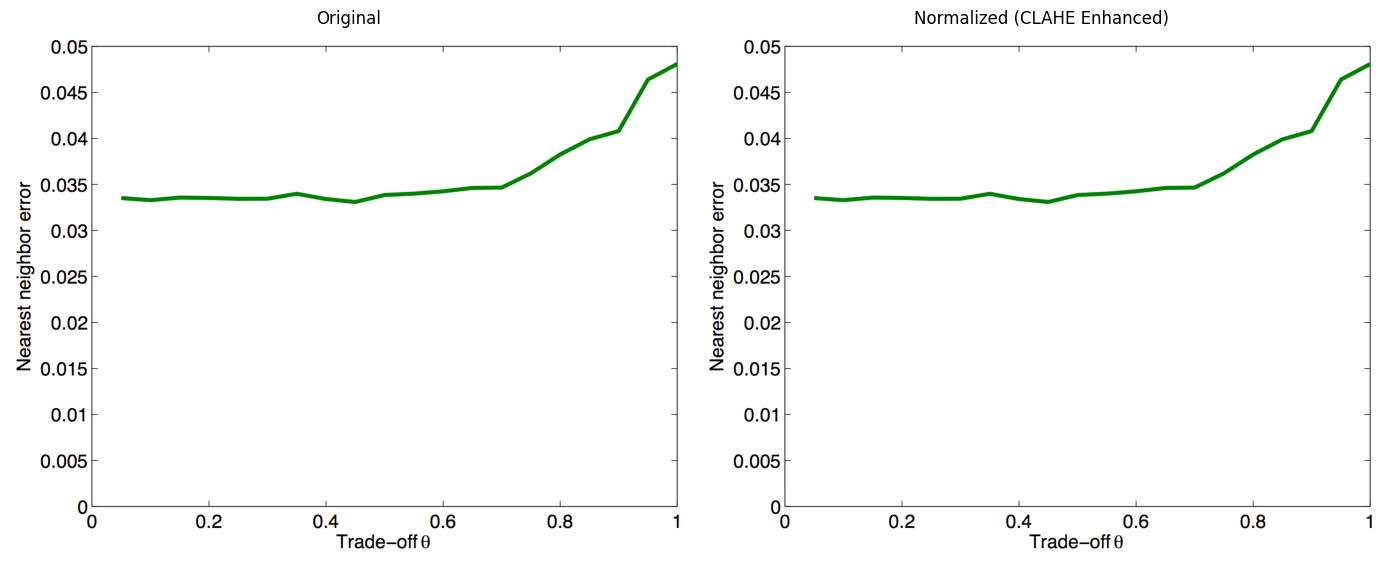

In [12]:
# Demonstrate normalization
if sample_images:
    img_path = sample_images[0]
    img_original = cv2.imread(str(img_path))
    img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    
    print(f"Processing: {img_path.name}")
    img_normalized = normalize_image(img_original.copy())
    
    # Compare
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    axes[0].imshow(img_original)
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    axes[1].imshow(img_normalized)
    axes[1].set_title("Normalized (CLAHE Enhanced)")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

## 5. Summary

### Stage 1 Operations:

| Operation | Tool | Purpose |
| --- | --- | --- |
| PDF Conversion | PyMuPDF | Convert PDF pages to images |
| Quality Check | OpenCV | Validate resolution, blur, contrast |
| Normalization | CLAHE | Enhance contrast for OCR |
| Resize | OpenCV | Limit max dimension |

### Output Schema:

```python
class CleanImage(BaseModel):
    image_path: Path
    original_path: Path
    page_number: int
    width: int
    height: int
    is_grayscale: bool
```

### Next: Stage 2 - Detection